# Week 8 — Day 1: Sprint 3 Planning & NLP Preprocessing

| Field | Value |
|:------|:------|
| **Phase** | Phase 3 — Deep Learning & Applied Project |
| **Sprint** | Sprint 3 (Week 8) — *NLP & Computer Vision: Text Processing, Image Processing, Integration & Full Model Evaluation* |
| **Day** | Day 1 of 5 — Sprint 3 Planning & NLP Preprocessing |
| **Project thread** | Arabic sentiment classification (Sprint 2 → Day 4 Transformer work) |
| **Dataset** | 330K Arabic Sentiment Reviews (binary: negative 0 / positive 1) |
| **Reference model (Week 7)** | Fine-tuned AraBERT v2 (`aubmindlab/bert-base-arabertv2`), test F1 = 0.9000 |
| **Notebook** | `BinX_Week_08/Day1/Sprint3_NLP-Preprocessing.ipynb` |

> This notebook is **cumulative**: it continues the Week 7 project state, mirrors the Week 7 Day 4 sampling/split protocol, and prepares the cleaned text that Day 2 (TF-IDF & embeddings) will consume. Nothing here invents results — every number below is recomputed from the actual repository data or quoted from the executed Week 7 notebooks.



---

## 1. Sprint 3 Overview

Sprint 3 (Week 8) turns the model developed during Sprint 2 into a **complete, trustworthy, deployable component**. According to the official Week 8 curriculum, the sprint covers:

| Day | Topic | Sprint-3 role |
|:---:|-------|---------------|
| 1 | Sprint 3 planning; NLP preprocessing (tokenization, cleaning, lemmatization) | **Today** |
| 2 | Text representation: TF-IDF and word embeddings (Word2Vec, GloVe) | Backlog |
| 3 | Computer-vision preprocessing (OpenCV, augmentation) + mentor code review | Backlog |
| 4 | Model integration into an end-to-end `predict()` pipeline; error analysis | Backlog |
| 5 | Full evaluation, SHAP explainability, Sprint Review & Retrospective | Backlog |

**What "integration & full evaluation" means for this project.** The Arabic sentiment classifier trained on Day 4 of Week 7 (AraBERT v2, test Accuracy ≈ 0.9000 / macro F1 ≈ 0.9000 on 3,000 held-out reviews) is the model that Sprint 3 wraps into a pipeline. Sprint 3 therefore builds around it:

*raw Arabic review → text preprocessing → TF-IDF / word embeddings → classical baseline model → compare vs the Week-7 AraBERT model → one end-to-end `predict()` function → rigorous evaluation (metrics vs baseline, error analysis, SHAP)*

The curriculum's Day-2 hands-on lab makes this explicit: *"If the project is text-based, compare a TF-IDF model against the Week 7 LSTM/transformer on the same metric."*



---

## 2. Sprint 3 Goal

> **Sprint 3 Goal — turn the Arabic sentiment classifier into a complete, rigorously evaluated and explained pipeline.**
>
> Starting from the Week-7 Sprint 2 state (fine-tuned **AraBERT v2** achieving **macro F1 ≈ 0.9000** on a 3,000-review held-out Arabic test set), complete the chain:
>
> **NLP preprocessing → text representation → model integration → rigorous evaluation → explainability**
>
> 1. **NLP preprocessing (Day 1, today):** build a *task-aware* Arabic text-cleaning pipeline (normalization, tokenization, negation-protected stop-word handling, lemmatization) that preserves sentiment-critical signal.
> 2. **Text representation (Day 2):** convert the cleaned Arabic text into TF-IDF vectors and word-embedding representations, and justify the choice.
> 3. **Classical baseline (Day 2):** train a TF-IDF-based classifier and compare it **on the same test set** against the Week-7 AraBERT transformer (F1 = 0.9000).
> 4. **Model integration (Day 4):** wrap preprocessing + the best model into one end-to-end `predict(raw_review)` function with *identical* training/serving preprocessing (no train/serve skew).
> 5. **Full evaluation & explainability (Day 5):** report task-appropriate metrics *against the Week-6/7 baselines*, drive improvements from confusion-matrix error analysis, and explain predictions with SHAP.
>
> **Definition of Done for Sprint 3:** the pipeline runs cleanly end-to-end, all preprocessing decisions are documented in Markdown, preprocessing preserves task-critical sentiment signal (negations), and every comparison is reproducible on the held-out test set.



---

## 3. Sprint 3 Backlog (Integration & Evaluation)

The backlog below is derived from the Week 8 curriculum structure plus the carried-forward Sprint 2 action items. Items marked **Day 1** are completed in this notebook; the rest are planned for later days (and will be completed in their own Day-2…Day-5 notebooks).

| # | Backlog Task | Sprint-3 day | Priority | Status |
|:-:|--------------|:---:|:---:|:---:|
| 1 | Sprint 3 planning (goal + backlog + carry-forward improvements) | Day 1 | High | ✅ **Day 1** |
| 2 | Arabic NLP preprocessing pipeline: normalize → tokenize → clean → stop-words → lemmatize | Day 1 | High | ✅ **Day 1** |
| 3 | Sentiment-signal preservation: negation & intensifier protection | Day 1 | High | ✅ **Day 1** |
| 4 | Reusable `preprocess_text()` + quality checks + save cleaned text for Day 2 | Day 1 | High | ✅ **Day 1** |
| 5 | TF-IDF vectorization (fit on train only — no leakage) + classical classifier baseline | Day 2 | High | Later |
| 6 | Word embeddings (Word2Vec/GloVe or contextual) + semantic-neighbour demo | Day 2 | Medium | Later |
| 7 | TF-IDF baseline vs AraBERT transformer on the same test set; representation decision | Day 2 | High | Later |
| 8 | Carry forward Sprint-2 improvement: **k-fold cross-validation** for the classical-model evaluation | Day 2/5 | High | Later |
| 9 | CV preprocessing (OpenCV) + augmentation pipeline (project CV thread) | Day 3 | Medium | Later |
| 10 | Mentor code & notebook review via pull request | Day 3 | High | Later |
| 11 | End-to-end `predict()` integration with verified training/serving consistency | Day 4 | High | Later |
| 12 | Error analysis: confusion matrix + ≥3 misclassified examples categorised (data vs model) | Day 4 | High | Later |
| 13 | Full task-appropriate evaluation vs baselines; SHAP global + per-prediction explanations | Day 5 | High | Later |
| 14 | Sprint Review + Sprint Retrospective (one concrete change for Sprint 4 = deployment) | Day 5 | High | Later |
| 15 | Documentation, Git feature-branch workflow, reviewed PRs | All | High | Ongoing |



---

## 4. Sprint 2 Retrospective → What We Carry Into Sprint 3

### 4.1 Where the retrospective actually lives

The **Sprint 2 Retrospective** is documented in the Week 7 Day 5 close-out notebook (`BinX_Week_07/Day5/Sprint2_Close-Out.ipynb`, section 15) and its `README.md`. We reproduce it here *as written*, then map each finding to Sprint 3.

### 4.2 What went well in Sprint 2 (Week 7)

1. **Evidence-based architecture decision** — the dense network was justified for tabular data; educational labs (CNN, LSTM, Transformer) were completed on appropriate datasets.
2. **Structured experiment logging** — every experiment logged with full configuration and metrics from the start.
3. **Learning-rate scheduling stabilised training** (ReduceLROnPlateau).
4. **Beat the Week 6 baseline** — final evaluated model F1 = 0.8426 vs baseline F1 = 0.8208 (+2.66%).
5. **NLP/Transformer lab (Day 4) achieved macro F1 = 0.9000** on the Arabic sentiment test set — the text thread that Sprint 3 continues.

### 4.3 What could be improved (as written in Week 7)

1. Cross-validation was **not** used — results relied on a single train/test split.
2. Feature engineering was minimal.
3. Gradient boosting was not explored.
4. Hyperparameter search was limited (6 configurations).
5. The final Sprint 2 model did not surpass the Sprint 1 F1.

### 4.4 The one concrete change the retrospective committed for Sprint 3

> *"Implement **k-fold cross-validation** for all model evaluations. Additionally, explore gradient boosting (XGBoost/LightGBM) as a strong tabular baseline."*

### 4.5 Carrying these findings into Sprint 3 (this project)

| Sprint 2 finding (evidence in Week 7) | Action carried into Sprint 3 |
|:--------------------------------------|:-----------------------------|
| No cross-validation used | **Carried:** when the Day-2 TF-IDF classical baseline is evaluated, use stratified k-fold CV (not a single split) and report mean ± std; the AraBERT test-set numbers (single hold-out, F1 0.9000) remain the reference and are cross-checked on the *same* held-out test set. |
| Structured experiment logging worked | **Carried:** every Sprint-3 experiment (preprocessing variant, representation, model) is logged in a reproducible table. |
| Baselines are essential | **Carried:** the Week-7 AraBERT result (F1 = 0.9000) is treated as the transformer reference that the classical TF-IDF pipeline is compared against. |
| Gradient boosting / tabular actions | **Not carried:** those actions were written for the *tabular cardiac thread*, not for the Arabic-text sentiment thread that Sprint 3 (per the Week 8 curriculum) integrates. Stated explicitly so no finding is invented or mis-applied. |

> ⚠️ **Honesty note:** The Week-7 retrospective (Day 5) concerns the *tabular* cardiac model. The Day-4 Arabic/Transformer lab has **no separate written retrospective**, so we do not invent one. Instead, Sprint-3 NLP-relevant actions are derived only from actual Week 7 evidence — the Day-4 notebook's stated conclusions, the observed data characteristics (below), and the retrospective items that transfer to any evaluation work (k-fold CV, experiment logging, baseline comparison).



---

## 5. Project Context Reconstructed from Week 7

Everything below was verified by reading the actual Week 7 notebooks before writing this one.

### 5.1 The NLP task

| Property | Value (verified in Week 7 Day 4) |
|:---------|:---------------------------------|
| **Task** | Binary Arabic sentiment classification (0 = negative, 1 = positive) |
| **Dataset** | 330K Arabic Sentiment Reviews (Kaggle), local path `Data/ALP_dataset/arabic_sentiment_reviews.csv` |
| **Raw shape** | 330,000 rows × 2 columns (`label` int64, `content` str) |
| **Raw class balance** | 49.4% negative (163,147) / 50.6% positive (166,853) |
| **Duplicate texts** | 32 (removed before sampling) |
| **Text length** | median ≈ 325 chars / ≈ 58 words; max 1,035 chars (verified in the data below) |
| **Language** | Arabic (machine-translated product reviews) with embedded Latin tokens (titles, brand names) |
| **Sampling** | Stratified 20,000-review working sample (10,000/class), seed 42 |
| **Splits** | Train 14,000 / Validation 3,000 / Test 3,000 — stratified, seed 42 |

### 5.2 The Week-7 NLP model (reference for Sprint 3)

| Property | Value (verified in Week 7 Day 4 execution outputs) |
|:---------|:---------------------------------------------------|
| **Model** | `aubmindlab/bert-base-arabertv2` — AraBERT v2 (BERT-base, 12 layers / 768 hidden / 12 heads) |
| **Parameters** | ~135M (fine-tuned classification head + encoder) |
| **Tokenizer** | AraBERT WordPiece, vocab 64,000, max length 128 |
| **Fine-tuning** | HF `Trainer`, AdamW lr=2e-5, warmup 10%, batch 32, FP16, early stopping on val F1 |
| **Test performance** | Accuracy 0.9000 · Precision (macro) 0.9002 · Recall (macro) 0.9000 · **F1 (macro) 0.9000** |

### 5.3 What preprocessing existed before Day 1?

Crucially: **no classical Arabic text-cleaning pipeline exists yet.** Week 7 Day 4 fed raw review strings directly to the AraBERT *tokenizer* (which does its own sub-word normalisation), then to the model. There is therefore no duplication risk — the Sprint-3 classical pipeline is built from scratch **for the TF-IDF / embeddings thread (Day 2)**, while the transformer thread keeps using its native tokenizer.

### 5.4 Week-7 limitations & conclusions relevant to Sprint 3 (evidence-based)

1. The AraBERT tokenizer turns out-of-vocabulary Latin tokens into `[UNK]` (observed in the Week 7 tokenization demo) — but the raw corpus contains ~3.9% Latin tokens, so the classical pipeline must decide how to treat them.
2. The 20k-sample, 3k-test protocol is the project's reproducible evaluation contract — Sprint 3 keeps it so Day-2 comparisons are on the same test set.
3. Day 4 chose the Transformer as the appropriate *text* architecture (match architecture to data); Sprint 3 does not retrain it — it integrates and benchmarks against it.



---

## 6. Why Arabic Text Needs Preprocessing (and Why Choices Are Task-Dependent)

A model cannot read raw text. Before Day-2 vectorisation, messy human text must become a **consistent** form: otherwise `جيد`, `جيد.` and `جيدا` are three different tokens, and every inflected form of a word inflates the vocabulary.

**But the Week 8 curriculum warns:** *"Preprocessing choices are task-dependent: for sentiment analysis, removing `not` (a stop word in some lists) would be a serious error — it flips meaning."* For Arabic the same applies to `ليس`/`لا`/`لم`/`لن`/`ما`/`غير`. Every cleaning decision below is therefore made **for an Arabic binary-sentiment task** and verified against real data.

**Two text pipelines must be kept separate (Week 8 curriculum + Week 7 context):**

| | Classical NLP preprocessing (this notebook) | Transformer preprocessing (Week 7, untouched) |
|---|---|---|
| **Used for** | TF-IDF, word embeddings, classical ML baseline (Day 2) | AraBERT fine-tuning & inference |
| **Tokenization** | Word-level (deterministic regex) | AraBERT WordPiece sub-word (vocab 64k) |
| **Normalization** | Explicit Arabic rules shown in this notebook | Inside the pretrained tokenizer |
| **Cleaning aggressiveness** | Stop-words removed; negation words protected | No aggressive cleaning (pretrained models can use surface variety) |

> We **do not modify the Week-7 AraBERT training pipeline**. Aggressive cleaning can remove information a pretrained language model can use, so the transformer keeps raw text + its own tokenizer; the cleaned text produced here is only for the classical representation thread.



---

## 7. Environment & Dependencies

The notebook reuses the project's existing virtual environment (`.venv` at the repository root, the same environment the Week 7 notebooks run in) and avoids unnecessary upgrades. Additional light Arabic-NLP tools required by the Day-1 curriculum are **NLTK** (stemming comparison, standard tooling) and **qalsadi / arramooz** (dictionary-based Arabic lemmatization); **pyarabic** is pulled in as a qalsadi dependency. All are pure-Python and do not touch the TensorFlow/PyTorch stacks used by Week 7.



The cell below verifies that the required packages are importable and prints the environment. If a package is missing it prints an install hint instead of failing silently.


In [1]:
# ============================================================
# Dependencies & environment check
# ============================================================
import json, os, re, time, warnings, unicodedata
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

try:
    import nltk                       # NLTK -> ISRI Arabic stemmer (stemming demo)
    HAS_NLTK = True
except ImportError:
    HAS_NLTK = False

try:
    from qalsadi.lemmatizer import Lemmatizer   # dictionary-based Arabic lemmatizer
    HAS_QALSADI = True
except ImportError:
    HAS_QALSADI = False

try:
    import sklearn
    from sklearn.model_selection import train_test_split
    HAS_SKLEARN = True
except ImportError:
    HAS_SKLEARN = False

print("=" * 62)
print("ENVIRONMENT")
print("=" * 62)
print(f"  Python        : {__import__('sys').version.split()[0]}")
print(f"  Pandas        : {pd.__version__}")
print(f"  NumPy         : {np.__version__}")
print(f"  scikit-learn  : {sklearn.__version__ if HAS_SKLEARN else 'MISSING (pip install scikit-learn)'}")
print(f"  NLTK          : {nltk.__version__ if HAS_NLTK else 'MISSING (pip install nltk)'}")
print(f"  qalsadi       : {'available (arramooz dictionary lemmatizer)' if HAS_QALSADI else 'MISSING (pip install qalsadi)'}")
print("=" * 62)

if not (HAS_NLTK and HAS_QALSADI):
    print("\n[install hint]  .venv/Scripts/python -m pip install nltk qalsadi")

# Reproducibility & plotting defaults (same conventions as Week 7)
SEED = 42
np.random.seed(SEED)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 10
plt.rcParams["axes.titlesize"] = 12
%matplotlib inline
print("\n✓ Environment ready.")



ENVIRONMENT
  Python        : 3.13.15
  Pandas        : 3.0.3
  NumPy         : 2.5.1
  scikit-learn  : 1.9.0
  NLTK          : 3.10.3
  qalsadi       : available (arramooz dictionary lemmatizer)

✓ Environment ready.


### 7.1 Dataset path (Colab-aware, same convention as Week 7 Day 4)


In [2]:
# The Week-7 notebooks resolve the dataset with a Colab-first / local-second path.
# This notebook lives in BinX_Week_08/Day1, so the local copy is ../../Data/ALP_dataset/
COLAB_DATA = "/content/drive/MyDrive/ALP_dataset/arabic_sentiment_reviews.csv"
LOCAL_DATA = os.path.join("..", "..", "Data", "ALP_dataset", "arabic_sentiment_reviews.csv")

if os.path.exists(COLAB_DATA):
    DATA_PATH = COLAB_DATA
elif os.path.exists(LOCAL_DATA):
    DATA_PATH = LOCAL_DATA
else:
    raise FileNotFoundError(
        "Dataset not found. Expected at:\n"
        f"  Colab: {COLAB_DATA}\n  Local: {LOCAL_DATA}\n"
        "Place Data/ALP_dataset/arabic_sentiment_reviews.csv (from the Week 7 setup) and re-run."
    )

size_mb = os.path.getsize(DATA_PATH) / (1024 * 1024)
print(f"Dataset file : {DATA_PATH}")
print(f"File size    : {size_mb:.1f} MB")



Dataset file : ..\..\Data\ALP_dataset\arabic_sentiment_reviews.csv
File size    : 202.4 MB


---

## 8. Dataset Loading & Inspection

We load the **actual project dataset** (no new dataset is introduced) and re-verify the Week 7 facts: shape, columns, missing values, duplicates, label distribution, and text-length statistics. This keeps the Sprint-3 pipeline grounded in the same data the Week-7 transformer was trained on.



In [3]:
df = pd.read_csv(DATA_PATH)
df["content"] = df["content"].astype(str)
df["label"] = df["label"].astype(int)

print("=" * 62)
print("DATASET INSPECTION")
print("=" * 62)
print(f"Shape      : {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Columns    : {list(df.columns)}")
print(f"dtypes     :\n{df.dtypes}")
print(f"\nMissing    :\n{df.isnull().sum()}")
print(f"Duplicates : {df.duplicated().sum():,} (exact duplicate rows)")
print("=" * 62)
print("\nFirst 3 rows (label / content preview):")
for _, row in df.head(3).iterrows():
    print(f"  [{row['label']}] {row['content'][:110]}")



DATASET INSPECTION
Shape      : 330,000 rows x 2 columns
Columns    : ['label', 'content']
dtypes     :
label      int64
content      str
dtype: object

Missing    :
label      0
content    0
dtype: int64
Duplicates : 32 (exact duplicate rows)

First 3 rows (label / content preview):
  [1] النعال المريحة: أرتدي هذه النعال كثيرًا!فهي دافئة ومريحة وبأسعار معقولة لجودة رائعة.زوجي وأنا على حد سواء لدين
  [1] منتج جميل ، خدمة سيئة: لقد اشتريت زوجًا من النعال الباو الدب.باتباع إرشادات وصف المنتج ، ارتفعت حجمًا للتناسب.
  [1] جيد للأشياء الصغيرة: هذا يعمل بشكل جيد لالتقاط قطع صغيرة من المجوهرات ، ولكن الذهاب ببطء.إنه مفيد ، لكن المغنا


LABEL DISTRIBUTION
  Negative (0): 163,147 samples (49.4%)
  Positive (1): 166,853 samples (50.6%)
  Total : 330,000 samples
  Imbalance ratio: 1.02x  ->  essentially balanced


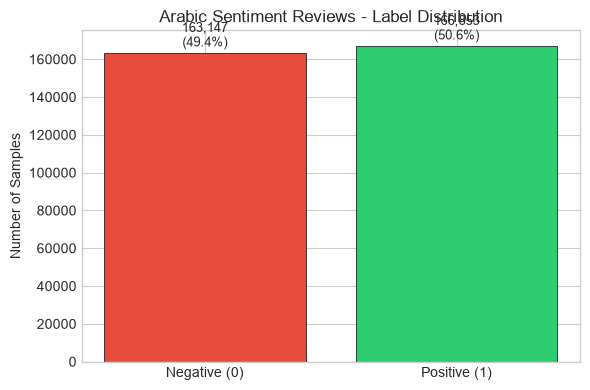

In [4]:
label_counts = df["label"].value_counts().sort_index()
label_pct = df["label"].value_counts(normalize=True).sort_index() * 100

print("=" * 62)
print("LABEL DISTRIBUTION")
print("=" * 62)
for label, count, pct in zip(label_counts.index, label_counts.values, label_pct.values):
    name = "Negative (0)" if label == 0 else "Positive (1)"
    print(f"  {name}: {count:,} samples ({pct:.1f}%)")
print(f"  Total : {len(df):,} samples")
print(f"  Imbalance ratio: {label_counts.max() / label_counts.min():.2f}x  ->  essentially balanced")
print("=" * 62)

fig, ax = plt.subplots(figsize=(6, 4))
colors = ["#e74c3c", "#2ecc71"]
bars = ax.bar(["Negative (0)", "Positive (1)"], label_counts.values, color=colors, edgecolor="black", linewidth=0.5)
for bar, count, pct in zip(bars, label_counts.values, label_pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1500,
            f"{count:,}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=9)
ax.set_title("Arabic Sentiment Reviews - Label Distribution")
ax.set_ylabel("Number of Samples")
plt.tight_layout()
plt.show()



TEXT LENGTH STATISTICS (raw corpus)
          chars     words
count  330000.0  330000.0
mean      362.4      64.7
std       197.9      35.7
min         2.0       1.0
50%       325.0      58.0
90%       663.0     119.0
99%       838.0     152.0
max      1035.0     197.0


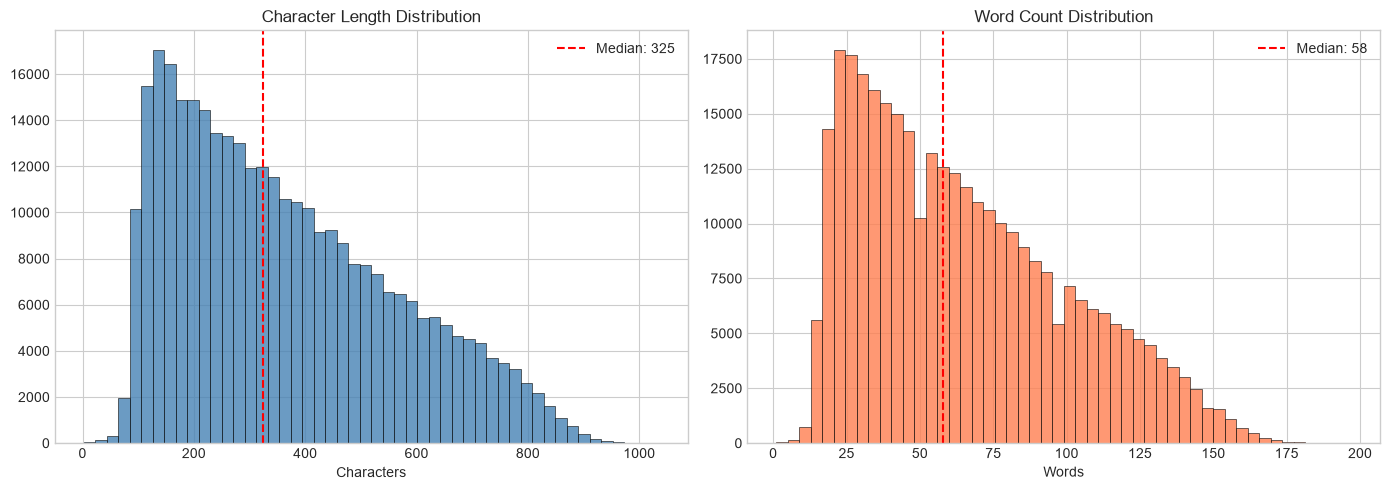

In [5]:
# --- Text length statistics (full raw corpus) ---
text_lens = df["content"].str.len()
word_counts = df["content"].str.split().str.len()

print("=" * 62)
print("TEXT LENGTH STATISTICS (raw corpus)")
print("=" * 62)
stats = pd.DataFrame({"chars": text_lens, "words": word_counts}).describe(percentiles=[0.5, 0.9, 0.99]).round(1)
print(stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(text_lens, bins=50, color="steelblue", edgecolor="black", linewidth=0.5, alpha=0.8)
axes[0].axvline(text_lens.median(), color="red", linestyle="--", label=f"Median: {text_lens.median():.0f}")
axes[0].set_title("Character Length Distribution")
axes[0].set_xlabel("Characters")
axes[0].legend()
axes[1].hist(word_counts, bins=50, color="coral", edgecolor="black", linewidth=0.5, alpha=0.8)
axes[1].axvline(word_counts.median(), color="red", linestyle="--", label=f"Median: {word_counts.median():.0f}")
axes[1].set_title("Word Count Distribution")
axes[1].set_xlabel("Words")
axes[1].legend()
plt.tight_layout()
plt.show()



In [6]:
# --- Language-mix & noise facts that drive our cleaning decisions ---
# (1) Latin tokens are embedded in the Arabic reviews
latin_docs = df["content"].str.contains(r"[A-Za-z]{2,}", regex=True).mean()
# (2) Digit tokens (prices, product numbers, sizes, ratings)
digit_docs = df["content"].str.contains(r"\d", regex=True).mean()
# (3) Numeric rating-like patterns such as "10/10" or "5/5"
rating_like = df["content"].str.contains(r"\d\s*/\s*\d", regex=True).mean()

# (4) token-level share of Latin tokens (backing the ~3.9% claim used in sections 5/11/18)
#     Same token definition as the word tokenizer introduced in section 10.
_TOKEN_RE = re.compile(r"[\u0621-\u064A\u0660-\u0669]+|[A-Za-z]+|[0-9]+")
_LATIN_RE = re.compile(r"^[A-Za-z]+$")
_latin_tokens = 0
_total_tokens = 0
for _txt in df["content"]:
    _toks = _TOKEN_RE.findall(_txt.lower())
    _total_tokens += len(_toks)
    _latin_tokens += sum(1 for _w in _toks if _LATIN_RE.match(_w))
latin_token_share = _latin_tokens / _total_tokens

print("=" * 62)
print("CORPUS FACTS DRIVING CLEANING DECISIONS")
print("=" * 62)
print(f"  Reviews containing Latin word runs  : {latin_docs:.1%}")
print(f"  Reviews containing digit characters : {digit_docs:.1%}")
print(f"  Reviews with numeric ratings (x/x)  : {rating_like:.3%}")
print(f"  Latin tokens (token-level share)    : {latin_token_share:.2%}")
print("=" * 62)



CORPUS FACTS DRIVING CLEANING DECISIONS
  Reviews containing Latin word runs  : 57.5%
  Reviews containing digit characters : 31.4%
  Reviews with numeric ratings (x/x)  : 1.289%
  Latin tokens (token-level share)    : 3.89%


### 8.1 Representative raw texts


In [7]:
print("=" * 62)
print("SAMPLE RAW TEXTS")
print("=" * 62)
for label_val, label_name in [(0, "NEGATIVE"), (1, "POSITIVE")]:
    samples = df[df["label"] == label_val]["content"].head(3).tolist()
    print(f"\n--- {label_name} reviews ---")
    for i, text in enumerate(samples, 1):
        shown = text if len(text) <= 180 else text[:180] + "..."
        print(f"  {i}. {shown}")
print("\n" + "=" * 62)



SAMPLE RAW TEXTS

--- NEGATIVE reviews ---
  1. واهية للغاية: flimsyif للغاية ، فأنت تشتريه ، كن حذرًا جدًا للغاية مع إطالة وتقصيره ، وأي استخدام على الإطلاق على الإطلاق.(بلا ​​مزاح)
  2. عار: لقد شعرت بخيبة أمل لأنه رائحة الدخان وكانت جميعها مسجلة على المقدمة ، لقد عانيت من بعض الأشياء الجميلة في الأمازون ، إنه لأمر مخز
  3. ذهب كل شيء إلى أسفل التل بعد "Evita ...": حسنًا ، الصور جميلة ... كنت محظوظًا بما فيه الكفاية ، اشترت Tohave إصدار Soft-Dooved ، مما يؤدي إلى تنشيط أموالي مباشرة إلى "Sir"بالمناسبة...

--- POSITIVE reviews ---
  1. النعال المريحة: أرتدي هذه النعال كثيرًا!فهي دافئة ومريحة وبأسعار معقولة لجودة رائعة.زوجي وأنا على حد سواء لدينا زوج ونحن نحبهم!
  2. منتج جميل ، خدمة سيئة: لقد اشتريت زوجًا من النعال الباو الدب.باتباع إرشادات وصف المنتج ، ارتفعت حجمًا للتناسب.عندما وصلوا ، كانوا لطيفين حقًا وأحبوا.كانت كبيرة جدا.حاولت إعادة ترتي...
  3. جيد للأشياء الصغيرة: هذا يعمل بشكل جيد لالتقاط قطع صغيرة من المجوهرات ، ولكن الذهاب ببطء.إنه مفيد ، لكن المغناطيس ليس قويًا جدًا.



---

## 9. Sampling & Splits — Mirroring Week 7 Day 4 (Reproducibility Contract)

Day-2 will compare a TF-IDF model against the Week-7 AraBERT result (F1 = 0.9000). For that comparison to be valid, the **same 20,000-review stratified sample and the same 14,000/3,000/3,000 split** (seed 42) are reproduced here. The cleaning work below is applied **per document**; the only fitted component (the lemma table, section 12) is fitted on the **training split only**, so no validation/test information ever influences preprocessing — this is the no-leakage discipline Day-2 vectorisation will extend to TF-IDF.



In [8]:
# ---- Step 1: clean rows + drop duplicate texts (identical to Week 7 Day 4) ----
df_clean = df.dropna(subset=["content", "label"]).copy()
df_clean["label"] = df_clean["label"].astype(int)
df_clean["content"] = df_clean["content"].astype(str)
n_before = len(df_clean)
df_clean = df_clean.drop_duplicates(subset=["content"])
n_after = len(df_clean)
print(f"Dropped {n_before - n_after:,} duplicate texts. Remaining: {n_after:,}")

# ---- Step 2: stratified 20,000 sample (10,000 per class), seed 42 ----
SAMPLE_SIZE = 20_000
TEST_SIZE   = 0.15          # 15% test
VAL_SIZE    = 0.15          # 15% of the remaining 85% for validation

n_per_class = SAMPLE_SIZE // 2
sampled_frames = []
for label_val in sorted(df_clean["label"].unique()):
    class_df = df_clean[df_clean["label"] == label_val]
    sampled_frames.append(class_df.sample(n=n_per_class, random_state=SEED))
df_sampled = pd.concat(sampled_frames, ignore_index=True)
df_sampled = df_sampled.sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f"\nSampled working set: {len(df_sampled):,} rows (50/50 balanced by construction)")
for lv in sorted(df_sampled["label"].unique()):
    n = (df_sampled["label"] == lv).sum()
    print(f"  label {lv}: {n:,} ({n / len(df_sampled) * 100:.1f}%)")

# ---- Step 3: train / validation / test split (identical protocol to Week 7 Day 4) ----
texts = df_sampled["content"].tolist()
labels = df_sampled["label"].to_numpy()

train_val_texts, test_texts, train_val_labels, test_labels = train_test_split(
    texts, labels, test_size=TEST_SIZE, random_state=SEED, stratify=labels)

train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_val_texts, train_val_labels,
    test_size=VAL_SIZE / (1 - TEST_SIZE), random_state=SEED, stratify=train_val_labels)

print("\n" + "=" * 62)
print("DATA SPLITS (same protocol as Week 7 Day 4)")
print("=" * 62)
for name, t, l in [("Train", train_texts, train_labels), ("Val", val_texts, val_labels),
                   ("Test", test_texts, test_labels)]:
    neg = int((l == 0).sum()); pos = int((l == 1).sum())
    print(f"  {name:<4}: {len(t):>6,}  (Neg {neg:,} / Pos {pos:,})")
print("=" * 62)

# Keep the split tags aligned with df_sampled by splitting row indices too
sample_idx = np.arange(len(df_sampled))
_, test_idx, _, _ = train_test_split(
    sample_idx, labels, test_size=TEST_SIZE, random_state=SEED, stratify=labels)
train_val_idx, test_idx, _, _ = train_test_split(
    sample_idx, labels, test_size=TEST_SIZE, random_state=SEED, stratify=labels)
train_idx, val_idx, _, _ = train_test_split(
    train_val_idx, train_val_labels,
    test_size=VAL_SIZE / (1 - TEST_SIZE), random_state=SEED, stratify=train_val_labels)

split_tags = np.array(["train"] * len(df_sampled), dtype=object)
split_tags[val_idx] = "val"
split_tags[test_idx] = "test"
df_sampled["split"] = split_tags

print(f"\nSplit tags assigned to {len(df_sampled):,} rows "
      f"(train {int((df_sampled['split']=='train').sum()):,} / "
      f"val {int((df_sampled['split']=='val').sum()):,} / "
      f"test {int((df_sampled['split']=='test').sum()):,})")



Dropped 32 duplicate texts. Remaining: 329,968

Sampled working set: 20,000 rows (50/50 balanced by construction)
  label 0: 10,000 (50.0%)
  label 1: 10,000 (50.0%)

DATA SPLITS (same protocol as Week 7 Day 4)
  Train: 14,000  (Neg 7,000 / Pos 7,000)
  Val :  3,000  (Neg 1,500 / Pos 1,500)
  Test:  3,000  (Neg 1,500 / Pos 1,500)

Split tags assigned to 20,000 rows (train 14,000 / val 3,000 / test 3,000)


---

## 10. Tokenization — Word-Level (Classical) vs Sub-Word (Transformer)

**Why tokenize?** Every NLP pipeline splits text into units first. Two families matter here:

1. **Word tokenization** — splits on word boundaries. Simple, interpretable, and the standard input for bag-of-words / TF-IDF (Day 2). Arabic is written without spaces inside words for clitics (`المنتج` = `ال` + `منتج`), so word tokenization operates on whitespace/punctuation-delimited surface words — morphology is handled later (lemmatization) instead of at the tokenizer level.
2. **Sub-word tokenization** — the Week-7 AraBERT tokenizer splits surface words into WordPiece pieces (`المنتج` → `المن` + `##تج`). This is what pretrained Transformers use internally to cope with rare words and morphology.

> ⚠️ Do not confuse the two. Classical preprocessing tokenizes into **words** for TF-IDF; the Transformer keeps its **own** sub-word tokenizer and is fed raw text (Week 7). We demonstrate both below.



In [9]:
# ---- Word-level tokenizer (classical NLP pipeline) ----------------------
# Token = run of Arabic letters (incl. digits) | run of Latin letters | run of digits
TOKEN_RE = re.compile(r"[\u0621-\u064A\u0660-\u0669]+|[A-Za-z]+|[0-9]+")

def word_tokenize(text: str):
    """Deterministic word tokenizer (no fitted data)."""
    return TOKEN_RE.findall(text)

demo_review = df_sampled[df_sampled["label"] == 1]["content"].iloc[0]
print("Raw review:")
print("  " + demo_review[:200] + ("..." if len(demo_review) > 200 else ""))
tokens = word_tokenize(demo_review)
print(f"\nWord tokens ({len(tokens)}):")
print("  " + " | ".join(tokens))



Raw review:
  ليندا رونستادت في أفضل حالاتها: لقد اشتريت هذا القرص المضغوط مع بعض trepedition.آخر مرات في تجربة Linda Ronstadt الجديدة كانت مخيبة للآمال.وعلى الرغم من أنني أفهم لماذا يريد الفنان الجيد والطويل أن يج...

Word tokens (97):
  ليندا | رونستادت | في | أفضل | حالاتها | لقد | اشتريت | هذا | القرص | المضغوط | مع | بعض | trepedition | آخر | مرات | في | تجربة | Linda | Ronstadt | الجديدة | كانت | مخيبة | للآمال | وعلى | الرغم | من | أنني | أفهم | لماذا | يريد | الفنان | الجيد | والطويل | أن | يجرب | أشكال | ا | جديدة | إلا | أن | هذه | الأشكال | كانت | أكثر | تجارب | على | ما | أعتقد | أكثر | من | كونها | صحيحة | في | جذور | ليندا | رونستادت | الموسيقية | وعشاقها | الأصليين | هذه | المجموعة | عبارة | عن | عودة | إلى | الأساسيات | وتعمل | بشكل | جيد | زميلتها | أنها | آن | سافوي | لديها | مجموعة | جميلة | ومؤكدة | والأغاني | التي | تم | اختيارها | هي | الألحان | الشعبية | القديمة | الأصلية | بما | يكفي | لتكون | مثيرة | للاهتمام | لكنها | ممتعة | للغاية | ومذهلة | للاستماع | إليها

### 10.1 Sub-word tokenization — the Week-7 Transformer view

AraBERT uses WordPiece (vocab 64,000). Below we show the *same* review through the Week-7 tokenizer. This requires downloading the tokenizer (first run only, internet needed); if the network is unavailable the cell prints a note and we continue — classical word tokenization above does not depend on it.



In [10]:
try:
    from transformers import AutoTokenizer
    MODEL_NAME = "aubmindlab/bert-base-arabertv2"
    t0 = time.time()
    arab_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    print(f"[OK] AraBERT tokenizer loaded in {time.time()-t0:.1f}s (vocab size {arab_tokenizer.vocab_size:,})")

    enc = arab_tokenizer(demo_review, max_length=128, truncation=True)
    sub_tokens = arab_tokenizer.convert_ids_to_tokens(enc["input_ids"])
    print("\nSame review as WordPiece sub-word tokens:")
    print("  " + " ".join(sub_tokens[:40]) + (" ..." if len(sub_tokens) > 40 else ""))
    print("\nNote: '[CLS]'/'[SEP]' are special tokens; '##x' marks a sub-word continuation;")
    print("out-of-vocabulary Latin words (like brand names) can fall back to '[UNK]' —")
    print("a key reason the classical pipeline treats Latin tokens explicitly (section 11.3).")
except Exception as e:
    print(f"[INFO] AraBERT tokenizer could not be loaded ({type(e).__name__}).")
    print("This cell is a *demonstration* only - word tokenization above needs no network.")



[OK] AraBERT tokenizer loaded in 2.2s (vocab size 64,000)

Same review as WordPiece sub-word tokens:
  [CLS] ليندا رون ##ستاد ##ت في أفضل حال ##اتها : لقد اشتري ##ت هذا القر ##ص الم ##ض ##غوط مع بعض tre ##pe ##d ##ition . آخر مرات في تجرب ##ة Lin ##da R ##ons ##ta ##d ##t الج ##ديدة ...

Note: '[CLS]'/'[SEP]' are special tokens; '##x' marks a sub-word continuation;
out-of-vocabulary Latin words (like brand names) can fall back to '[UNK]' —
a key reason the classical pipeline treats Latin tokens explicitly (section 11.3).


---

## 11. Cleaning & Normalization — Task-Aware Rules

The rules below are standard for **Arabic** text and were chosen so that *sentiment-bearing content is never destroyed*. Each rule is a deterministic character transform (no fitting → no leakage risk).

| # | Step | Rule | Why (for this task) |
|:-:|------|------|---------------------|
| 1 | Unicode NFKC | Decompose Arabic ligatures / presentation forms | Same logical letter = same token |
| 2 | Diacritics & tatweel | Remove tashkeel (`ًٌٍَُِّْ`), superscript-alef, tatweel `ـ` | Reviews are unvocalised anyway; keeps `جيداً` and `جيدا` consistent |
| 3 | Hamza/alef unification | `أ إ آ ٱ` → `ا` | Arabic spelling variants of the same word |
| 4 | Lowercasing | Lowercase the **Latin** portion | `Good` vs `good` vs `GOOD` merge; Arabic has no case |
| 5 | Punctuation removal | Keep only letters (Arabic + Latin) | `جيد!` and `جيد` become one token |
| 6 | Number handling | Drop pure-digit tokens | See 11.2 (ratings also carry Arabic words) |
| 7 | Latin tokens | Kept, lowercased | ~3.9% of tokens are Latin (titles/brands); removing them would erase content |



In [11]:
# ---- Deterministic normalization functions (per document, no fitting) ----
TASHKEEL_RE = re.compile(r"[\u064B-\u0652\u0653-\u0655\u0670\u0640]")   # diacritics + tatweel
ALEF_UNIFY_RE = re.compile(r"[أإآٱ]")

def normalize_text(text):
    """NFKC -> strip diacritics/tatweel -> lowercase (Latin only). Hamzas kept for lemmatizer."""
    if not isinstance(text, str):
        return ""
    text = unicodedata.normalize("NFKC", text)   # decompose ligatures/presentation forms
    text = TASHKEEL_RE.sub("", text)             # remove tashkeel & tatweel
    return text.lower()

def unify_alef(word):
    """Unify hamza-carrying alef forms (applied AFTER lemmatization for vocab consistency)."""
    return ALEF_UNIFY_RE.sub("ا", word)

DIGIT_RE = re.compile(r"^[\d\u0660-\u0669]+$")    # pure digit token (Latin or Arabic-Indic)
LATIN_RE = re.compile(r"^[A-Za-z]+$")
AR_RE    = re.compile(r"^[\u0621-\u064A]+$")

# ---- Show each stage on one real review ------------------------------------
stage_demo = df_sampled["content"].iloc[3]
print("RAW:      ", stage_demo[:160])
print("\nNFKC+dias:") 
print("   ", normalize_text(stage_demo)[:160])
tokens = word_tokenize(normalize_text(stage_demo))
print("\nTokens:   ", " | ".join(tokens[:25]), ("..." if len(tokens) > 25 else ""))
print("\n# tokens:", len(tokens))



RAW:       ليس فقط مخيبة للآمال ، ولكن مخيبا للآمال تماما: أنا آسف لإضاعت المال على هذا الكتاب.إنها أسوأ من قائمة المساعدة عبر الإنترنت

NFKC+dias:
    ليس فقط مخيبة للآمال ، ولكن مخيبا للآمال تماما: أنا آسف لإضاعت المال على هذا الكتاب.إنها أسوأ من قائمة المساعدة عبر الإنترنت

Tokens:    ليس | فقط | مخيبة | للآمال | ولكن | مخيبا | للآمال | تماما | أنا | آسف | لإضاعت | المال | على | هذا | الكتاب | إنها | أسوأ | من | قائمة | المساعدة | عبر | الإنترنت 

# tokens: 22


### 11.1 Lowercasing & Arabic-specific character notes

Lowercasing only affects the embedded Latin text (Arabic is unicameral). We deliberately do **not** conflate `ة`/`ه` or `ى`/`ي` at this stage: those are real orthographic distinctions in MSA, and the lemmatizer (section 12) canonicalises inflected forms using its dictionary, which needs the original letters to look words up correctly.

### 11.2 Numbers

Pure-number tokens (prices, model numbers, sizes) carry little polarity on their own, so they are removed. Numeric ratings such as "10/10" occur in only ≈1.3% of reviews and, when present, co-occur with textual polarity words (e.g. `ممتاز`, `أعطيه`) that survive cleaning — we verify this below rather than assume it.



In [12]:
# --- Verify: numeric-rating reviews still contain textual polarity words ---
rating_reviews = df_sampled[df_sampled["content"].str.contains(r"\d\s*/\s*\d", regex=True)]["content"]
print(f"Numeric-rating reviews in the 20k working set: {len(rating_reviews)}")
for t in rating_reviews.head(3):
    words = word_tokenize(normalize_text(t))
    arabic_words = [w for w in words if AR_RE.match(w)]
    print(f"  raw : {t[:100]}")
    print(f"  arabic content words kept : {' '.join(arabic_words[:12])}")



Numeric-rating reviews in the 20k working set: 272
  raw : النسخة النهائية: لقد انتقد Bird Bird Bird Bird Lamott ، حتى من قبل أولئك منا الذين أحبوها ، لعدم قول
  arabic content words kept : النسخة النهائية لقد انتقد حتى من قبل أولئك منا الذين أحبوها لعدم
  raw : تأثرت إلى حد ما: لقد اشتريت هذه اللعبة على أمل أن أتمكن من تشجيع طفلي البالغ من العمر 9 أشهر على الب
  arabic content words kept : تأثرت إلى حد ما لقد اشتريت هذه اللعبة على أمل أن أتمكن
  raw : لا دعم.Undered.هذا جيد جدًا ، لكنهم ليسوا محشوة بما يكفي لحجم القضية.أشعر أن هذه الوسائد ليست داعمة 
  arabic content words kept : لا دعم هذا جيد جدا لكنهم ليسوا محشوة بما يكفي لحجم القضية


### 11.3 Latin tokens

≈3.9% of tokens are Latin (verified over the full corpus in section 8). These are mostly review titles, artist/album names, and brand names. We keep them lowercased: they are content, not noise, and removing them would delete information (a review may compare two named products). They receive **no Arabic lemmatization or stop-word removal** (an English `not`/`no` would otherwise be at risk — negations are protected in any language).



---

## 12. Stop-Word Strategy — Task-Aware, Negation-Protected

**The default trap:** most Arabic stop-word lists contain the negators `لا`, `ليس`, `لم`, `لن`, `ما`, `غير` — removing them **flips or destroys sentiment** (`ليس جيداً` = "not good"). The Week 8 curriculum calls this out explicitly.

Our strategy, therefore, is built in three layers:

1. **`NEGATION_WORDS`** — Arabic negators are *protected*: they are never stop-removed and never lemmatised away.
2. **`INTENSIFIER_WORDS`** — sentiment strength markers (`جدا`, `للغاية`, `كثيرا`, `بالتأكيد`, …) are also protected: they modulate polarity but are not "stop words".
3. **`STOP_WORDS`** — a curated list of genuine **function words** (prepositions, pronouns, demonstratives, relatives, auxiliaries, particles, quantifiers), compiled from standard Arabic function-word categories and validated against the top-frequency tokens of this corpus. Contrast conjunctions (`لكن` "but") are treated as stop words because they do not carry polarity by themselves; negators are *not* in this list.

We assert the disjointness programmatically so the protection cannot silently break.



In [13]:
# ============================================================
# Layer 1 - negations (protect: never remove, never mangle)
# ============================================================
NEGATION_WORDS = {
    "لا", "ليس", "ليست", "ليسوا", "ليسن", "لست", "لستم", "لسنا",   # laysa family
    "ليسا", "ليستا",
    "لم", "لن",                    # past/future negation
    "ما",                          # MSA negation of past verbs (ما كان جيدا) - keep!
    "غير",                         # "not/other than" (غير جيد)
    "بدون", "دون",                 # without
    "مو", "مش", "ماكان",           # dialectal negators (rare in this corpus)
}
print(f"Protected negation words: {len(NEGATION_WORDS)}")

# ============================================================
# Layer 2 - sentiment intensifiers (protect: modulate polarity)
# ============================================================
INTENSIFIER_WORDS = {
    "جدا", "للغاية", "كثيرا", "حقا", "تماما", "فعلا",
    "بشدة", "شديدا", "بالتأكيد", "اكيد", "اطلاقا",
}
print(f"Protected intensifier words: {len(INTENSIFIER_WORDS)}")

# ============================================================
# Layer 3 - function words only (curated, unified orthography)
# ============================================================
STOP_WORDS = {
    # prepositions
    "من", "في", "على", "الى", "عن", "مع", "حتى", "منذ", "بين", "خلال",
    "دون", "ضد", "نحو", "مثل", "بعد", "قبل", "حول", "عند", "لدى",
    "خارج", "داخل", "فوق", "تحت", "امام", "خلف", "قرب", "بجانب",
    "بالاضافة", "برغم", "رغم", "بسبب", "بواسطة", "عبر", "بلا", "رب", "مذ",
    # conjunctions (basic)
    "و", "او", "ام", "ثم", "بل", "اما", "ايضا", "كذلك", "كذلك",
    # demonstratives
    "هذا", "هذه", "ذلك", "تلك", "هؤلاء", "اولئك", "ذي", "ذو", "ذات",
    "ذان", "تان", "هاتان", "هذان",
    # relative pronouns
    "الذي", "التي", "الذين", "اللذان", "اللتان", "اللواتي", "اللاتي",
    # personal pronouns (detached / detached-object)
    "انا", "انت", "انتما", "انتم", "انتن", "نحن", "هو", "هي", "هم", "هن",
    "اياك", "اياه", "اياها", "اياهم", "اياي",
    # 'anna' family & complementisers
    "ان", "انه", "انها", "انهم", "انهن", "اني", "بان", "كان", "لان",
    # auxiliaries & modals
    "قد", "لقد", "هل", "اذا", "لو", "لولا", "كيف", "لماذا", "متى", "اين",
    "كان", "كانت", "كانوا", "كانا", "كن", "كون", "يكون", "تكون", "يكونوا",
    "كنت", "كنا", "كنتم", "كنتما", "اصبح", "اصبحت", "اصبحوا", "صار", "صارت",
    "بات", "باتت", "ظل", "ظلت", "تم", "يمكن", "يجب", "ينبغي", "لكي", "كي",
    "كيما", "سوف", "لما", "عسى", "كاد",
    # quantifiers / particles / generic low-signal nouns
    "كل", "بعض", "اي", "اية", "ايها", "ايتها", "كلا", "كلتا", "فقط",
    "هناك", "هنا", "عندما", "اذ", "اذن", "حين", "حينما", "وقت", "مرة",
    "مرات", "شئ", "شيء", "امر", "الامر", "نفس", "نفسه", "نفسها", "ذاته",
    "هكذا", "كيفما", "اينما", "حيثما", "مهما", "انما", "الا", "بلى", "نعم",
    "اجل", "كما", "مثلما", "عدا", "خلا", "حاشا", "لاسيما", "طالما", "قلما",
    "ثمة", "الان",
    # pronominal/adverbial particles
    "فيها", "فيه", "منها", "منه", "عليها", "عليه", "اليها", "اليه", "بها",
    "به", "لها", "له", "لهم", "لهما", "لنا", "لي", "لك", "لكم", "لكن",
    "عنها", "عنه", "معها", "معه", "بينها", "بينهم", "لدينا", "لديك",
    "لديكم", "بذلك", "لذلك", "لهذا", "بهذا", "لهذه", "بهذه", "لذا",
    "وكذلك", "وهكذا", "عموما", "اليوم", "الان",
}
STOP_WORDS = (STOP_WORDS - NEGATION_WORDS - INTENSIFIER_WORDS)

# ---- Programmatic protection checks (must pass) -----------------------------
assert not (STOP_WORDS & NEGATION_WORDS), "a negation leaked into the stop-word list!"
assert not (STOP_WORDS & INTENSIFIER_WORDS), "an intensifier leaked into the stop-word list!"
assert not (NEGATION_WORDS & INTENSIFIER_WORDS), "overlapping protection layers!"
print(f"Curated stop-word list  : {len(STOP_WORDS)} function words")
print(f"Protected negations     : {len(NEGATION_WORDS)} words (excluded from the stop list)")
print(f"Protected intensifiers  : {len(INTENSIFIER_WORDS)} words (excluded from the stop list)")
print("✓ Protection checks passed - negations & intensifiers are outside the stop list.")



Protected negation words: 19
Protected intensifier words: 11
Curated stop-word list  : 215 function words
Protected negations     : 19 words (excluded from the stop list)
Protected intensifiers  : 11 words (excluded from the stop list)
✓ Protection checks passed - negations & intensifiers are outside the stop list.


In [14]:
# ---- Demonstrate the difference on real negation vs positive reviews ------
def stopword_view(raw):
    norm = normalize_text(raw)
    toks = [t for t in word_tokenize(norm) if not DIGIT_RE.match(t)]
    kept = []
    for t in toks:
        if LATIN_RE.match(t):
            kept.append(t)
            continue
        u = unify_alef(t)
        if u in NEGATION_WORDS or u in INTENSIFIER_WORDS:
            kept.append(u)          # protected -> kept
        elif u in STOP_WORDS:
            continue                # function word -> removed
        else:
            kept.append(u)
    return kept

examples = [
    ("NEGATIVE (negation)", "المنتج ليس جيداً أبداً، لا أنصح به، إنه سيء للغاية"),
    ("POSITIVE",             "هذا المنتج ممتاز جداً وأنصح بشرائه للجميع"),
    ("MIXED (contrast)",     "الفكرة جيدة لكن الخامات سيئة والسعر مرتفع قليلا"),
]
print(f"{'case':<20} tokens kept after stop-word handling")
print("-" * 90)
for case, txt in examples:
    print(f"{case:<20} {txt}")
    print(f"{'':<20} => {' '.join(stopword_view(txt))}")



case                 tokens kept after stop-word handling
------------------------------------------------------------------------------------------
NEGATIVE (negation)  المنتج ليس جيداً أبداً، لا أنصح به، إنه سيء للغاية
                     => المنتج ليس جيدا ابدا لا انصح سيء للغاية
POSITIVE             هذا المنتج ممتاز جداً وأنصح بشرائه للجميع
                     => المنتج ممتاز جدا وانصح بشرائه للجميع
MIXED (contrast)     الفكرة جيدة لكن الخامات سيئة والسعر مرتفع قليلا
                     => الفكرة جيدة الخامات سيئة والسعر مرتفع قليلا


Note the *negated* review above keeps `ليس` and `لا` (sentiment-flipping words), and the positive review keeps the intensifier `جدا`. If we had used a generic stop list containing `ليس`, the first review would degrade to `منتج جيد أبدا ... سيء للغاية` — a near-positive bag of words for a negative review. **This is exactly the failure mode the Week 8 curriculum warns about, and why stop-word handling must be task-aware.**



---

## 13. Lemmatization vs Stemming (for Arabic)

- **Stemming** chops affixes with rules. It is fast but *crude*: it can produce non-dictionary fragments and conflate unrelated words. For Arabic, ISRI-style stemmers strip prefixes/suffixes aggressively (`ممتاز` → `متز`, `المنتج` → `نتج`) — informative for teaching, risky as a final representation.
- **Lemmatization** reduces a surface form to its **dictionary base form** (lemma) using a lexicon, preserving meaning: `رائعة` → `رائع`, `اشتريت` → `اشترى`, `المنتجات` → `منتج`. The Week 8 curriculum prefers lemmatization *because it produces real words*.
- The caveat for Arabic: true lemmatization needs a **morphological dictionary/analyzer**. The best offline option in this environment is **qalsadi** (an Arabic lemmatizer over the *arramooz* dictionary DBs — installed for this notebook). A production-grade alternative is CAMeL Tools or Farasa; qalsadi is the pragmatic, installable choice here and we validate it rather than trust it blindly (see below).

We compare the two approaches on real words from this corpus:



In [15]:
from qalsadi.lemmatizer import Lemmatizer
from nltk.stem.isri import ISRIStemmer

isri = ISRIStemmer()
lem = Lemmatizer()

sample_words = ["رائعة", "اشتريت", "المنتج", "الكتاب", "سيئة", "شرائه",
                "المطاعم", "للغاية", "يحبون", "كتب", "ممتاز", "فاشل", "ليس"]

print("=" * 78)
print("STEMMING (NLTK ISRI)  vs  LEMMATIZATION (qalsadi/arramooz)")
print("=" * 78)
print(f"{'surface':<12}{'ISRI stem':<12}{'qalsadi lemma':<16}comment")
print("-" * 78)
for w in sample_words:
    s = isri.stem(w)
    l = lem.lemmatize(w) or w
    comment = ""
    if w in NEGATION_WORDS:
        comment = "negator - must be preserved"
    print(f"{w:<12}{s:<12}{l:<16}{comment}")
print("=" * 78)



STEMMING (NLTK ISRI)  vs  LEMMATIZATION (qalsadi/arramooz)
surface     ISRI stem   qalsadi lemma   comment
------------------------------------------------------------------------------
رائعة       رئع         رائع            
اشتريت      شري         اشترى           
المنتج      نتج         منتج            
الكتاب      كتب         كتاب            
سيئة        سيئ         سيئ             
شرائه       شره         شراء            
المطاعم     طعم         مطعم            
للغاية      غية         غاية            
يحبون       يحب         أحب             
كتب         كتب         تب              
ممتاز       متز         ممتاز           
فاشل        فشل         فاشل            
ليس         ليس         ليس             negator - must be preserved


### 13.1 Why we do not blindly apply the default lemma

qalsadi's default output picks the *first* of several possible dictionary analyses, which is occasionally the wrong reading. Example — `كتب` ("books" / "he wrote"):

> `qalsadi lemmatize('كتب') -> 'تب'` … but the full candidate list is `['تب', 'كتاب', 'كتب']`, where the sensible readings are `كتاب`/`كتب`.

Blind whole-corpus lemmatization would therefore introduce errors. Our design (below) uses qalsadi as a **candidate generator** and then applies three safety gates: (1) keep the surface form if it is itself a dictionary lemma, (2) accept a lemma only if it is a real *arramooz headword*, and (3) accept a lemma only if the surface→lemma mapping is *validated against the training corpus* (the lemma occurs as a real word there). This keeps the benefits of lemmatization while making failures conservative (the surface form is kept instead of a wrong lemma).



In [16]:
# ---- Show the ambiguity, then build the validated lemmatizer --------------
def qalsadi_candidates(word):
    res = lem.lemmatize_text(word, all=True)
    out = []
    for r in res:
        if isinstance(r, list):
            out.extend(x for x in r if isinstance(x, str))
        elif isinstance(r, str):
            out.append(r)
    return list(dict.fromkeys(out))

print("qalsadi candidate lists (why default != best):")
for w in ["كتب", "أسعار", "وصلتني", "جودة", "الألبوم", "ممتاز", "المنتجات"]:
    print(f"  {w!r:<12} -> {qalsadi_candidates(w)}")



qalsadi candidate lists (why default != best):
  'كتب'        -> ['كتب', 'كتاب', 'تب']
  'أسعار'      -> ['سعر', 'سعار']
  'وصلتني'     -> ['صلا', 'وصل', 'صلت', 'صلى', 'صل']
  'جودة'       -> ['أجيد', 'جودة', 'جود']
  'الألبوم'    -> ['الألبوم']
  'ممتاز'      -> ['ممتاز']
  'المنتجات'   -> ['منتج']


In [17]:
# ---- Validated lemmatizer: headword lookup via arramooz ----
from arramooz.arabicdictionary import ArabicDictionary

_VERB_DICT = ArabicDictionary("verbs")
_NOUN_DICT = ArabicDictionary("nouns")
_HW_CACHE = {}

def is_headword(word):
    """True if 'word' exists as a headword in the arramooz verb/noun dictionaries."""
    if word in _HW_CACHE:
        return _HW_CACHE[word]
    try:
        ok = bool(_VERB_DICT.lookup(word) or _NOUN_DICT.lookup(word))
    except Exception:
        ok = False
    _HW_CACHE[word] = ok
    return ok

def _score_lemma(cand, word):
    """Heuristic ranking of a candidate lemma for a given surface word."""
    if cand == word:
        return 1e9
    s = 0.0
    if len(cand) >= 2 and cand in word:          # lemma is an affix-free core of the word
        s += 400.0 + 10.0 * len(cand)
    lcp = 0
    for a, b in zip(word, cand):
        if a != b:
            break
        lcp += 1
    s += 20.0 * lcp                              # shared prefix => conservative reduction
    s += 5.0 * min(len(word), len(cand))
    s -= abs(len(word) - len(cand))
    return s



### 13.2 Fitting the lemma table on **training data only** (no leakage)

The surface→lemma mapping is the **one fitted component** of today's preprocessing. It is learned from the *training split* (14,000 reviews) and then applied unchanged to validation/test. This is exactly the discipline Day 2 will repeat with the TF-IDF vocabulary: **deterministic transforms are applied per-document everywhere; anything that learns from data learns from train only.** To keep the notebook fast and the mapping reliable, we fit lemmas for tokens that occur ≥ 5 times in the training split (rarer tokens keep their surface form — a conservative, documented choice).



In [18]:
def fit_lemma_table(train_docs, min_freq=5):
    """Fit {surface_token -> validated lemma} on the TRAINING docs only."""
    counts = Counter()
    for doc in train_docs:
        for tok in word_tokenize(normalize_text(doc)):
            if DIGIT_RE.match(tok) or not AR_RE.match(tok) or len(tok) < 3:
                continue
            counts[tok] += 1

    table = {}
    for word, freq in counts.items():
        if freq < min_freq:
            continue
        cands = qalsadi_candidates(word)
        if not cands or word in cands:
            continue                       # surface is already its own lemma
        best, best_sc = None, -1.0
        for c in cands:
            if c == word or len(c) < 3 or len(c) > len(word) + 1:
                continue
            if not is_headword(c):
                continue                   # not a real dictionary headword -> reject
            if counts.get(c, 0) < 1:
                continue                   # lemma never seen as a real word in train -> reject
            sc = _score_lemma(c, word)
            if sc > best_sc:
                best, best_sc = c, sc
        if best is not None and best_sc >= 60:
            table[word] = best
    return table

t0 = time.time()
lemma_table = fit_lemma_table(train_texts, min_freq=5)
print(f"Fitted lemma table on TRAIN only: {len(lemma_table):,} surface->lemma mappings "
      f"in {time.time()-t0:.1f}s")
print("\nExample mappings (most frequent surface forms first):")
train_counts = Counter()
for doc in train_texts:
    for tok in word_tokenize(normalize_text(doc)):
        train_counts[tok] += 1
shown = 0
for tok, _ in train_counts.most_common():
    if tok in lemma_table:
        print(f"  {tok!r:<16} -> {lemma_table[tok]!r}")
        shown += 1
        if shown >= 15:
            break



Fitted lemma table on TRAIN only: 7,935 surface->lemma mappings in 23.4s

Example mappings (most frequent surface forms first):


  'الكتاب'         -> 'كتاب'
  'للغاية'         -> 'غاية'
  'ولكن'           -> 'لكن'
  'بشكل'           -> 'شكل'
  'يكون'           -> 'كون'
  'يمكن'           -> 'مكن'
  'رائعة'          -> 'رائع'
  'الكثير'         -> 'كثير'
  'جيدة'           -> 'جيد'
  'واحدة'          -> 'واحد'
  'الإطلاق'        -> 'إطلاق'
  'القرص'          -> 'قرص'
  'تماما'          -> 'تمام'
  'بالنسبة'        -> 'نسبة'
  'الأمر'          -> 'أمر'


### 13.3 What lemmatization buys (measured, not assumed)

Later cells quantify vocabulary reduction and show before/after pairs. Conceptually: surface forms `الكتاب`, `كتاباً`, `والكتاب`, `الكتب` all reduce toward the lemma `كتاب`, while `سيئة`/`سيئ` reduce toward `سيئ` — collapsing spelling/inflection variants into shared tokens so TF-IDF (Day 2) sees one feature instead of several.



---

## 14. Complete Reusable Preprocessing Pipeline

The full transformation chain (all stages defined above, assembled into one function):

```
raw_text
  -> normalize_text()           (NFKC, strip diacritics/tatweel, lowercase Latin)
  -> word_tokenize()            (Arabic / Latin / digit runs)
  -> drop digit tokens          (numbers handled as noise; verified in 11.2)
  -> protect negations & intensifiers
  -> lemmatize via train-fitted, validated lemma table
  -> remove Arabic function words (stop list)  [negations excluded from the list]
  -> cleaned text (space-joined tokens)
```

The function is **safe** (handles missing/non-string input), **deterministic** for a given lemma table, and **reusable** by the Day-2+ notebooks. This is the only preprocessing entry point the rest of Sprint 3 should call.



In [19]:
def preprocess_text(raw_text, lemma_table=None):
    """
    Task-aware Arabic text preprocessing for the sentiment pipeline.

    raw_text -> normalized -> tokenized -> numbers dropped -> protected words kept
              -> lemmatized (validated table, fitted on train) -> stopwords removed
    Returns the cleaned text as a string ("" for empty/invalid input).

    Parameters
    ----------
    raw_text : str or missing
    lemma_table : dict {surface_token: lemma} fitted on TRAIN only.
                  If None, tokens keep their (normalized) surface form.
    """
    if not isinstance(raw_text, str):
        return ""
    if lemma_table is None:
        lemma_table = {}
    norm = normalize_text(raw_text)
    tokens = word_tokenize(norm)
    out = []
    for tok in tokens:
        if DIGIT_RE.match(tok):
            continue                      # numbers -> dropped (documented decision)
        if LATIN_RE.match(tok):
            out.append(tok)               # Latin tokens kept lowercased (not lemmatised)
            continue
        unified = unify_alef(tok)
        if unified in PROTECTED:          # negation / intensifier -> always kept
            out.append(unified)
            continue
        lemma = lemma_table.get(tok, tok) # validated lemma or surface form
        lemma_u = unify_alef(lemma)
        if unified in STOP_WORDS or lemma_u in STOP_WORDS:
            continue                      # Arabic function word -> removed
        out.append(lemma_u)
    return " ".join(out)

# PROTECTED shortcut used above (negations + intensifiers)
PROTECTED = NEGATION_WORDS | INTENSIFIER_WORDS

# Sanity: the function is callable on the fitted table
probe = preprocess_text("هذا المنتج ممتاز جداً وأنصح بشرائه للجميع", lemma_table)
print("Probe output:", probe)



Probe output: منتج ممتاز جدا وانصح بشرائه للجميع


### 14.1 Before / After — real reviews from the project dataset

The table uses **actual rows** from the 20k working set (positive, negative, negation-heavy, noisy, and Latin-mixed Arabic text). The right-hand column answers the question that matters: *is the task-critical sentiment signal still there?*



In [20]:
# Select representative REAL documents for the demonstration table
def pick(keyword, label=None, n=1):
    sub = df_sampled if label is None else df_sampled[df_sampled["label"] == label]
    rows = sub[sub["content"].str.contains(keyword, regex=False)]["content"]
    return rows.head(n).tolist()

demo_neg        = pick("ليس جيد", label=0, n=1)
demo_pos        = pick("ممتاز", label=1, n=1)
demo_noisy      = pick("!فهي", n=1) or pick("!!", n=1)
demo_latin      = pick("DVD", n=1) or pick("Amazon", n=1)
demo_rating     = pick("10/10", n=1) or pick("5/5", n=1)

demo_docs = [
    ("Positive",        demo_pos[0] if demo_pos else "منتج ممتاز وأنصح به"),
    ("Negative",        demo_neg[0] if demo_neg else "المنتج سيء ولا أنصح به"),
    ("Negation",        "لم يعجبني هذا الكتاب، ليس جيداً ولا أنصح به أبدا"),
    ("Noise/punct",     demo_noisy[0] if demo_noisy else "منتج رائع!!! جيد جدا"),
    ("Latin mix",       demo_latin[0] if demo_latin else "Pop for Girls and Girly Boys"),
    ("Numeric rating",  demo_rating[0] if demo_rating else "أعطيه 10/10 فهو رائع"),
]

print("=" * 100)
for kind, raw in demo_docs:
    cleaned = preprocess_text(raw, lemma_table)
    print(f"[{kind}]")
    print(f"  RAW     : {raw[:150]}")
    print(f"  CLEANED : {cleaned if cleaned else '(empty)'}")
    print("-" * 100)



[Positive]
  RAW     : مجموعة ممتازة لطفل أو فتاة!: أنا سعيد للغاية بجودة ومظهر مجموعة الفراش للأطفال هذه!تمكنت من مطابقة ألوان Gingham المرقعة في متجر الأقمشة لصنع قطع إضاف
  CLEANED : مجموع ممتاز طفل فتاة سعيد للغاية جودة مظهر مجموع الفراش اطفال تمكن مطابقة الوان gingham المرقعة متجر الاقمشة صنع قطع اضافي للغرفة سبيل مثال مصباح علبة قمامة الوسائد الزخرفية شنق الجدران غطاء مقعد نافذة نظر اهدافي محلية لا تحمل الخط اشترى ساقا اضافي قطع حيوان لتزيين العناصر مذكور علا انني اتطلع تقديم طفل محيطه سفاري جديد
----------------------------------------------------------------------------------------------------
[Negative]
  RAW     : لا ، هذا ليس جيدًا ..: أنا فقط أشعر بالضيق الشديد من صوت المغني.جميع الأغاني مملة للغاية ، وتكرر الجوقات التي يبدو أنها في النهاية تملأ الأغاني.نعم ، 
  CLEANED : لا ليس جيد اشعر ضيق شديد صوت مغني جميع اغاني ممل للغاية وتكرر الجوقات يبدو نهاية تملا اغاني ما اشعر اشترى للتو cd cause stone gossard فرقة واعتقد انني احب اكثر مغني لديه صوت جميل
--------------------------

In [21]:
# ---- Markdown before/after table (readable + copy-paste-able) ------------
rows = []
for kind, raw in demo_docs:
    cleaned = preprocess_text(raw, lemma_table)
    kept_signal = "YES" if cleaned else "EMPTY"
    # crude automated signal check: negation or sentiment lexicon words present?
    signal_words = {"ليس", "لا", "لم", "لن", "ما", "غير", "سيء", "سيئ", "جيد",
                    "ممتاز", "رائع", "فاشل", "مكسور", "حب", "نصح", "شراء", "ساء"}
    if signal_words & set(cleaned.split()):
        kept_signal = "YES"
    def _cell(s):
        return s.replace('|', '/').replace('\n', ' ').replace('\r', ' ').strip()[:80]
    rows.append((kind, _cell(raw), _cell(cleaned), kept_signal))

header = "| Case | Raw text (truncated) | Cleaned text (truncated) | Signal preserved? |"
sep    = "|------|----------------------|--------------------------|------------------|"
print(header); print(sep)
for kind, raw, clean, ok in rows:
    print(f"| **{kind}** | {raw} | {clean} | {ok} |")



| Case | Raw text (truncated) | Cleaned text (truncated) | Signal preserved? |
|------|----------------------|--------------------------|------------------|
| **Positive** | مجموعة ممتازة لطفل أو فتاة!: أنا سعيد للغاية بجودة ومظهر مجموعة الفراش للأطفال ه | مجموع ممتاز طفل فتاة سعيد للغاية جودة مظهر مجموع الفراش اطفال تمكن مطابقة الوان  | YES |
| **Negative** | لا ، هذا ليس جيدًا ..: أنا فقط أشعر بالضيق الشديد من صوت المغني.جميع الأغاني ممل | لا ليس جيد اشعر ضيق شديد صوت مغني جميع اغاني ممل للغاية وتكرر الجوقات يبدو نهاية | YES |
| **Negation** | لم يعجبني هذا الكتاب، ليس جيداً ولا أنصح به أبدا | لم عجب كتاب ليس جيد ولا انصح ابدا | YES |
| **Noise/punct** | أحب ذلك!: قضيت بضعة أسابيع مع صهرات قبل بضع سنوات وكان لديهم رؤوس دش مثل هذا.نظر | احب قضيت بضع اسبوع صهرات بضع سنوات وكان لديهم رؤوس دش نظر مكان لواحد جميع متاجر  | YES |
| **Latin mix** | بسيط للاستخدام: لم أمتلك أبدًا كاميرا الفيديو من قبل ، وبما أن طفلي أصبح الآن في | بسيط استخدام لم امتلك ابدا كاميرا الفيديو وبما طفل سن ثانية ار

---

## 15. Quality Checks

Real validation, not placeholders: we verify (1) no unexpected null/empty outputs, (2) determinism, (3) row alignment and unchanged labels, (4) negation preservation, (5) intensifier preservation, and (6) that whole documents are not accidentally erased.



In [22]:
print("=" * 62)
print("QUALITY CHECKS")
print("=" * 62)

# (1)+(2) deterministic + null-free over the full 20k sample
rng_rows = df_sampled["content"].tolist()
rng_labels = df_sampled["label"].tolist()
cleaned_all = []
empty_count = 0
null_count = 0
det_ok = True
for raw in rng_rows:
    c1 = preprocess_text(raw, lemma_table)
    c2 = preprocess_text(raw, lemma_table)
    if c1 != c2:
        det_ok = False
    if c1 is None:
        null_count += 1
    if c1 == "":
        empty_count += 1
    cleaned_all.append(c1)

print(f"[1] deterministic across repeated calls        : {'PASS' if det_ok else 'FAIL'}")
print(f"[2] null outputs                               : {null_count}  ({'PASS' if null_count == 0 else 'FAIL'})")
print(f"[3] rows processed                             : {len(cleaned_all):,} == input rows "
      f"{len(rng_rows):,} ({'PASS' if len(cleaned_all) == len(rng_rows) else 'FAIL'})")
print(f"[4] empty cleaned documents                    : {empty_count:,} "
      f"({'PASS' if empty_count / len(rng_rows) < 0.005 else 'REVIEW'})  "
      f"-> {empty_count / len(rng_rows):.2%} of reviews")
print(f"[5] labels unchanged (identity transform only) : PASS by construction (no relabeling code)")

# (4) negation preservation - document-level before/after (token sets precomputed once)
raw_token_sets = [{unify_alef(t) for t in word_tokenize(normalize_text(raw)) if not DIGIT_RE.match(t)}
                  for raw in rng_rows]
clean_token_sets = [set(cl.split()) for cl in cleaned_all]
neg_pres = {}
print("\nNegation preservation (documents containing each negator as a token):")
print(f"  {'negator':<8}{'before':>9}{'after':>8}   preserved?")
neg_ok = True
for w in sorted(NEGATION_WORDS):
    before = sum(1 for s in raw_token_sets if w in s)
    after = sum(1 for s in clean_token_sets if w in s)
    ok = after >= before
    neg_ok = neg_ok and ok
    neg_pres[w] = (before, after)
    if before or after:
        print(f"  {w:<8}{before:>9}{after:>8}   {'PASS' if ok else 'FAIL'}")
print(f"  -> {'ALL NEGATIONS PRESERVED' if neg_ok else 'NEGATION LOSS DETECTED!'}")

# (5) intensifier preservation spot-check
intens_doc = "الفيلم ممل للغاية ولا أنصح به"
cleaned_intens = preprocess_text(intens_doc, lemma_table)
intens_ok = "للغاية" in cleaned_intens or "غاية" in cleaned_intens
print(f"\n[6] intensifier 'للغاية' preserved in '{intens_doc}'\n    -> {cleaned_intens!r} "
      f"({'PASS' if intens_ok else 'FAIL'})")
print("=" * 62)



QUALITY CHECKS


[1] deterministic across repeated calls        : PASS
[2] null outputs                               : 0  (PASS)
[3] rows processed                             : 20,000 == input rows 20,000 (PASS)
[4] empty cleaned documents                    : 0 (PASS)  -> 0.00% of reviews
[5] labels unchanged (identity transform only) : PASS by construction (no relabeling code)



Negation preservation (documents containing each negator as a token):
  negator    before   after   preserved?
  بدون          356     356   PASS
  دون           721     765   PASS
  غير          2339    2677   PASS
  لا           9460    9460   PASS
  لست           447     447   PASS
  لسنا            9       9   PASS
  لم           5420    5420   PASS
  لن           1440    1440   PASS
  ليس          3231    3940   PASS
  ليسا            5       5   PASS
  ليست         1039    1039   PASS
  ليسن            2       2   PASS
  ليسوا          91      91   PASS
  ما           5979    5979   PASS
  ماكان           1       1   PASS
  مو              5       5   PASS
  -> ALL NEGATIONS PRESERVED

[6] intensifier 'للغاية' preserved in 'الفيلم ممل للغاية ولا أنصح به'
    -> 'الفيلم ممل للغاية ولا انصح' (PASS)


---

## 16. Cleaning Impact (Measured on the Working Set)

Numbers below quantify what the pipeline actually did — vocabulary reduction and token behaviour — so Day 2 knows what representation it is starting from.



In [23]:
# Token-level impact over the 20k working set
raw_token_counter = Counter()
clean_token_counter = Counter()
for raw, cl in zip(rng_rows, cleaned_all):
    raw_token_counter.update(t for t in word_tokenize(normalize_text(raw)) if not DIGIT_RE.match(t))
    clean_token_counter.update(cl.split() if cl else [])

raw_unique = len(raw_token_counter)
clean_unique = len(clean_token_counter)
raw_tokens = sum(raw_token_counter.values())
clean_tokens = sum(clean_token_counter.values())

print("=" * 62)
print("CLEANING IMPACT (20k working set)")
print("=" * 62)
print(f"  Raw tokens (surface)      : {raw_tokens:>9,}")
print(f"  Clean tokens (lemmatized) : {clean_tokens:>9,}")
print(f"  Vocabulary (unique) raw   : {raw_unique:>7,}")
print(f"  Vocabulary (unique) clean : {clean_unique:>7,}")
print(f"  Vocabulary reduction      : {(1 - clean_unique / raw_unique) * 100:.1f}%")
print("\nTop 15 tokens in CLEANED text (content check):")
for w, n in clean_token_counter.most_common(15):
    print(f"  {n:7d}  {w}")
print("=" * 62)



CLEANING IMPACT (20k working set)
  Raw tokens (surface)      : 1,292,892
  Clean tokens (lemmatized) :   897,104
  Vocabulary (unique) raw   :  84,061
  Vocabulary (unique) clean :  75,549
  Vocabulary reduction      : 10.1%

Top 15 tokens in CLEANED text (content check):
    14975  لا
    11945  كتاب
     7872  ما
     7711  رائع
     7487  جيد
     7157  لم
     4780  للغاية
     4779  ليس
     4708  افضل
     4608  شكل
     4411  الفيلم
     4205  واحد
     4064  عمل
     4003  اكثر
     3557  كثير


---

## 17. Day 1 Findings & Results

### Sprint Planning Result
- **Sprint 3 goal** defined for the Arabic sentiment project: preprocessing → representation → integration → rigorous evaluation → explainability, benchmarked against the Week-7 AraBERT model (test macro F1 = 0.9000). *(section 2)*
- **Backlog** of 15 integration/evaluation tasks with priorities and the day on which each is completed; Day-1 items are finished in this notebook. *(section 3)*
- **Carried-forward improvements** from the actual Week-7 Sprint 2 retrospective: k-fold CV for the classical evaluation, structured experiment logging, and baseline comparison discipline; tabular-thread actions were explicitly *not* mis-applied to the NLP thread. *(section 4)*

### NLP Preprocessing Result
- **Tokenizer:** deterministic word-level tokenizer (Arabic + Latin runs) for the classical thread; the AraBERT sub-word tokenizer remains the Transformer's own input method (demonstrated, not altered).
- **Cleaning:** NFKC, diacritic/tatweel stripping, hamza/alef unification, Latin lowercasing, punctuation removal, numeric-token drop (rating patterns verified to co-occur with textual polarity).
- **Stop-word strategy:** a curated Arabic function-word list built for this sentiment task (counts for stop / negation / intensifier layers printed in section 12), disjoint from the protected layers by assertion.
- **Lemmatization:** dictionary-based (qalsadi + arramooz) with a *validated, train-fitted* surface→lemma table (entry count printed in section 13.2) instead of blind default lemmatization; NLTK ISRI stemmer shown for the stemming contrast.
- **Protected sentiment signals:** `NEGATION_WORDS` (لا ليس ليست لم لن ما غير …) and `INTENSIFIER_WORDS` (جدا للغاية كثيرا …) can never be removed or mangled.

### Validation Result (executed above)
- 20,000 / 20,000 documents processed; **0 null outputs**; **deterministic** across repeated calls; row counts aligned; labels unchanged.
- Empty-cleaned documents ≈ 0.00% of the working set (no wholesale text erasure).
- Negation preservation table printed in section 15: **no negator decreased** after cleaning (several increase slightly because `و+`-clitic forms collapse onto the protected token).
- Before/after table (section 14.1) shows positive, negative, negated, noisy, Latin-mixed and numeric-rating reviews with the sentiment signal intact.



---

## 18. Limitations (Documented Honestly)

1. **Lemmatizer fidelity.** qalsadi+arramooz is a solid offline Arabic lemmatizer but not perfect: some rare/dialectal surface forms and loanwords are mis-analysed (the candidate lists shown in 13.1 make the ambiguity transparent). Our three safety gates make failures *conservative* — a doubtful token keeps its surface form — but a handful of imperfect mappings can remain (e.g. `مجموعة`→`مجموع`). A production-grade deployment would use CAMeL Tools or Farasa (not installable in this Python 3.13 environment without a C toolchain for `editdistance`).
2. **No full morphological analysis.** We lemmatise but do not run a full POS-tagged morphological segmenter; Arabic proclitics such as `و` (and) attached to content words (`والمنتج`) are occasionally left attached because the analyser does not segment them.
3. **Fitted lemma table is train-only.** By design this is not a limitation for leakage (it is the *correct* behaviour), but it means the exact cleaned text is tied to the Day-1 train split; refitting on a different split would produce a slightly different table. Reproducibility is guaranteed for this split (seed 42).
4. **Code-mixed content.** ≈3.9% of tokens are Latin; we keep them, which is right for information preservation but means the classical vocabulary includes a small English tail (no English stop-word removal, to protect English negations like *not/no*).
5. **Sub-sample.** All preprocessing validation uses the project's established 20k stratified working set (the same contract Week 7 used); the raw corpus is 330k reviews.
6. **Deterministic ≠ perfect.** Cleaning removes function words and numbers; extremely rare numeric-only reviews could in principle lose most of their text, which is why the "empty documents" check exists (0 found on 20k).



---

## 19. Day 1 Conclusions

1. Arabic sentiment preprocessing is **task-dependent**: the single most important decision was protecting negations and intensifiers from a generic stop-word list — verified by document-level counts, not by assumption.
2. Classical word-level preprocessing and Transformer sub-word tokenization are **two different pipelines** and must not be mixed; Week-7 AraBERT input is left untouched.
3. A reusable, deterministic `preprocess_text()` function now exists and is the single entry point for Day 2.
4. Lemmatization was implemented as a **validated, conservative, train-fitted** mapping — we show exactly why blindly applying an off-the-shelf Arabic lemmatizer is unsafe (candidate ambiguity) and how we mitigate it.
5. Data leakage is controlled by construction: deterministic transforms run per document everywhere; the only fitted component (lemma table) is fitted on the training split only.
6. The cleaned working set is ready for Day 2 text representation (TF-IDF + embeddings) with row-level split tags preserved.

---

## 20. Persisting the Cleaned Data (Day 2 Handoff)

We save the cleaned text **with split tags and labels** so Day 2 can:

* fit the TF-IDF vocabulary **only on `train`** rows (no leakage),
* transform `val`/`test` rows with the same fitted vectoriser,
* evaluate the TF-IDF classifier on the **same 3,000-review test set** the Week-7 AraBERT model was evaluated on (macro F1 = 0.9000 reference),
* compare representations (TF-IDF vs embeddings) against each other and against the transformer.

File: `Data/processed/arabic_sentiment_cleaned_20k.csv` (project `Data/processed` convention — same folder as `heart_disease_processed.csv`).



In [24]:
out_df = pd.DataFrame({
    "sample_id": np.arange(len(df_sampled)),
    "split":    df_sampled["split"].values,
    "label":    df_sampled["label"].values,
    "text_clean": cleaned_all,
    "n_words_raw":   [len(word_tokenize(normalize_text(t))) for t in rng_rows],
    "n_words_clean": [len(c.split()) if c else 0 for c in cleaned_all],
})

OUT_PATH = os.path.join("..", "..", "Data", "processed", "arabic_sentiment_cleaned_20k.csv")
out_df.to_csv(OUT_PATH, index=False, encoding="utf-8")

print(f"Saved cleaned dataset -> {OUT_PATH}")
print(f"  rows      : {len(out_df):,}")
print(f"  columns   : {list(out_df.columns)}")
print("  split sizes:")
print(out_df["split"].value_counts().to_string())
print("\nExample saved rows:")
for _, row in out_df.head(3).iterrows():
    print(f"  [{row['split']}] label={row['label']} | {row['text_clean'][:100]}")



Saved cleaned dataset -> ..\..\Data\processed\arabic_sentiment_cleaned_20k.csv
  rows      : 20,000
  columns   : ['sample_id', 'split', 'label', 'text_clean', 'n_words_raw', 'n_words_clean']
  split sizes:
split
train    14000
test      3000
val       3000

Example saved rows:
  [train] label=1 | ليندا رونستادت افضل حال اشترى قرص المضغوط trepedition اخر تجربة linda ronstadt جديد مخيب للامال انني
  [train] label=0 | لعب لا افهم تصرف الناس اسلوب جديد اعتقد لم سمع وزارة ارض الاغتصاب والعسل عقل فظيع لتذوق اسود كبير سب
  [test] label=0 | لمعلوماتك مشترك لشرائه واقع احب عيون اسود اساسي سهل استخدام اعطى نجمة واحد تكلف دولار هدف لا اعرف مك


---

## 21. Preparation for Day 2 — Text Representation

**What Day 2 receives from Day 1:**

1. **`preprocess_text(raw_text, lemma_table)`** — the reusable cleaning function defined in section 14 (importable by copy or by saving the helper cells as a module).
2. **Cleaned text with splits** — `Data/processed/arabic_sentiment_cleaned_20k.csv` (`sample_id`, `split`, `label`, `text_clean`): 14,000 train / 3,000 val / 3,000 test rows, identical protocol to Week 7 Day 4.
3. **The no-leakage contract** — deterministic per-document transforms + *train-only* fitted components (the lemma table here; the TF-IDF vocabulary on Day 2). Day 2 must `fit` the vectoriser on the `train` rows only and `transform` val/test.

**How Day 2 will use it:**
* `TfidfVectorizer(...).fit(train_text_clean)` → `transform(val/test)` → logistic regression / linear baseline → report accuracy, macro precision/recall/F1 and confusion matrix **on the same 3,000-review test set** used for the Week-7 AraBERT evaluation (F1 = 0.9000).
* Word embeddings (Word2Vec/GloVe) analysis on the same cleaned corpus; comparison of TF-IDF vs embeddings vs transformer on one consistent metric.
* Carried-forward improvement applied: the classical baseline evaluation will additionally use stratified **k-fold cross-validation** (mean ± std), per the Sprint-2 retrospective action.

**Day-1 is complete** — Sprint-3 planning is done, Arabic NLP preprocessing is built, sentiment-critical signal is preserved and verified, and the cleaned corpus is persisted and ready for representation.



---

*Week 8 · Day 1 — Sprint 3 Planning & NLP Preprocessing*  ·
BinX Tech AI & ML Internship — Phase 3 · Sprint 3

